In [18]:
import bchlib
import zlib
import struct
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Optional, but makes heatmaps much easier

VARIABLES

In [ ]:
DATA_SIZE = 512  # Data packet size (Payload)
OOB_SIZE = 69    # Out-Of-Band physical space
CRC_SIZE = 4     # 32-bit Checksum
a = 2
b = 10
c = 1e4

FUNCTIONS FOR BCH AND CRC


In [20]:
def crc32_le(data: bytes) -> bytes:
    """Calculates the 32-bit CRC of the data."""
    return struct.pack("<I", zlib.crc32(data) & 0xFFFFFFFF)

def encode_sector(data: bytes):
    """Write Phase: Calculates CRC, then protects [Data + CRC] with BCH."""
    crc = crc32_le(data)
    protected_payload = data + crc           # Combine data and digital fingerprint
    ecc = bch.encode(protected_payload)      # BCH calculates parity on BOTH
    
    # Build the physical OOB (ECC + CRC + Padding)
    oob = ecc + crc 
    oob += b"\xFF" * (OOB_SIZE - len(oob)) # Padding with 0xFF to reach the OOB size, 
    # the nomenclature is "FF" because in NAND flash, unprogrammed bits are represented by 1s (0xFF per byte)
    return data, oob

def decode_sector(data: bytes, oob: bytes):
    """Read Phase: BCH corrects [Data + CRC], then the CRC validates everything."""
    # 1. Extraction from OOB
    ecc = oob[:bch.ecc_bytes]
    stored_crc = oob[bch.ecc_bytes : bch.ecc_bytes + CRC_SIZE]
    
    # 2. Prepare mutable buffers for BCH correction
    payload_buf = bytearray(data + stored_crc)
    ecc_buf = bytearray(ecc)
    
    # 3. The Surgeon (BCH) detects and corrects errors
    n_errors = bch.decode(payload_buf, ecc_buf)
    if n_errors > 0:
        bch.correct(payload_buf, ecc_buf)
        
    # 4. Separate the repaired data from the repaired CRC
    corrected_data = bytes(payload_buf[:-CRC_SIZE])
    corrected_crc = bytes(payload_buf[-CRC_SIZE:])
    
    # 5. The Inspector (CRC) verifies the surgeon's work
    if n_errors < 0 or crc32_le(corrected_data) != corrected_crc:
        return corrected_data, "UNCORRECTABLE", n_errors
        
    status = "CORRECTED_OK" if n_errors > 0 else "OK"
    return corrected_data, status, n_errors

def decode_sector_wo_CRC(data: bytes, oob: bytes):
    """Read Phase: BCH corrects [Data + CRC], NO CRC validation."""
    ecc = oob[:bch.ecc_bytes]
    stored_crc = oob[bch.ecc_bytes : bch.ecc_bytes + CRC_SIZE]
    payload_buf = bytearray(data + stored_crc)
    ecc_buf = bytearray(ecc)
    n_errors = bch.decode(payload_buf, ecc_buf)
    if n_errors > 0:
        bch.correct(payload_buf, ecc_buf)
    corrected_data = bytes(payload_buf[:-CRC_SIZE])
    corrected_crc = bytes(payload_buf[-CRC_SIZE:])
    if n_errors < 0:
        return corrected_data, "UNCORRECTABLE", n_errors
    status = "CORRECTED_OK" if n_errors > 0 else "OK"
    return corrected_data, status, n_errors

TEST WITH CRC

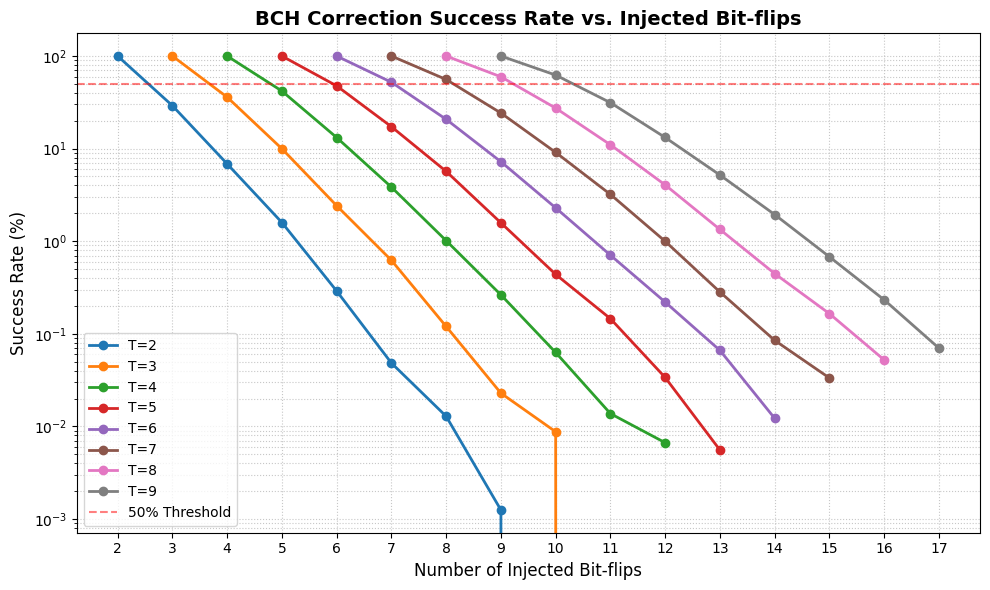

In [38]:
results = {}

for T in range(a, b):
    bch = bchlib.BCH(T, m=14) 
    bit_flips = T - 1 
    for _ in range(10):
        for n in range(int(c) * (bit_flips + 1 - T)):
            original_data = bytes(random.choices(range(256), k=DATA_SIZE))
            
            # 1. Encode
            data_out, oob_out = encode_sector(original_data)
            
            # 2. Corrupt (Dati + OOB)
            full_packet = bytearray(data_out + oob_out)
            for _ in range(bit_flips):
                # pos = random.randint(0, len(full_packet) - 1)
                # full_packet[pos] ^= (1 << random.randint(0, 7)) 
                pos = random.randint(0, len(full_packet) - 1)
                full_packet[pos] ^= 1 
                
            # 3. Decode 
            corrupted_data_part = bytes(full_packet[:DATA_SIZE])
            corrupted_oob_part = bytes(full_packet[DATA_SIZE:])
            
            recovered_data, status, errs = decode_sector(corrupted_data_part, corrupted_oob_part)
            
            # 4. Storage
            key = (T, bit_flips)
            if key not in results: results[key] = []
            results[key].append(1 if status != "UNCORRECTABLE" else 0)
        bit_flips +=1


import matplotlib.pyplot as plt
import seaborn as sns # Optional, but makes heatmaps much easier
import numpy as np

# ---------------------------------------------------------
# 1. PROCESS THE DATA
# Calculate the mean success rate (%) for each (T, bit_flips) pair
# ---------------------------------------------------------
success_rates = {}
for key, outcomes in results.items():
    success_rates[key] = np.mean(outcomes) * 100

# Extract unique T values and bit-flips to setup the axes
T_values = sorted(list(set([k[0] for k in success_rates.keys()])))
bit_flip_values = sorted(list(set([k[1] for k in success_rates.keys()])))

# ---------------------------------------------------------
# PLOT 1: Line Chart (Success Rate vs. Bit-flips)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

for T in T_values:
    # 1. Extract ONLY the data points that exist for this specific T
    t_data = [(k[1], rate) for k, rate in success_rates.items() if k[0] == T]
    
    # 2. Sort the data by bit-flips (x-axis) so the line draws cleanly left-to-right
    t_data.sort(key=lambda x: x[0]) 
    
    # 3. Separate into x and y lists
    if t_data:
        x_vals = [item[0] for item in t_data]
        y_vals = [item[1] for item in t_data]
        
        plt.semilogy(x_vals, y_vals, marker='o', linewidth=2, label=f'T={T}')

plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='50% Threshold')
plt.title('BCH Correction Success Rate vs. Injected Bit-flips', fontsize=14, fontweight='bold')
plt.xlabel('Number of Injected Bit-flips', fontsize=12)
plt.ylabel('Success Rate (%)', fontsize=12)
plt.xticks(bit_flip_values)
plt.grid(True, linestyle=':', alpha=0.7, which='both')
plt.legend()
plt.tight_layout()
plt.show()

TEST WITHOUT CRC AND PLOT

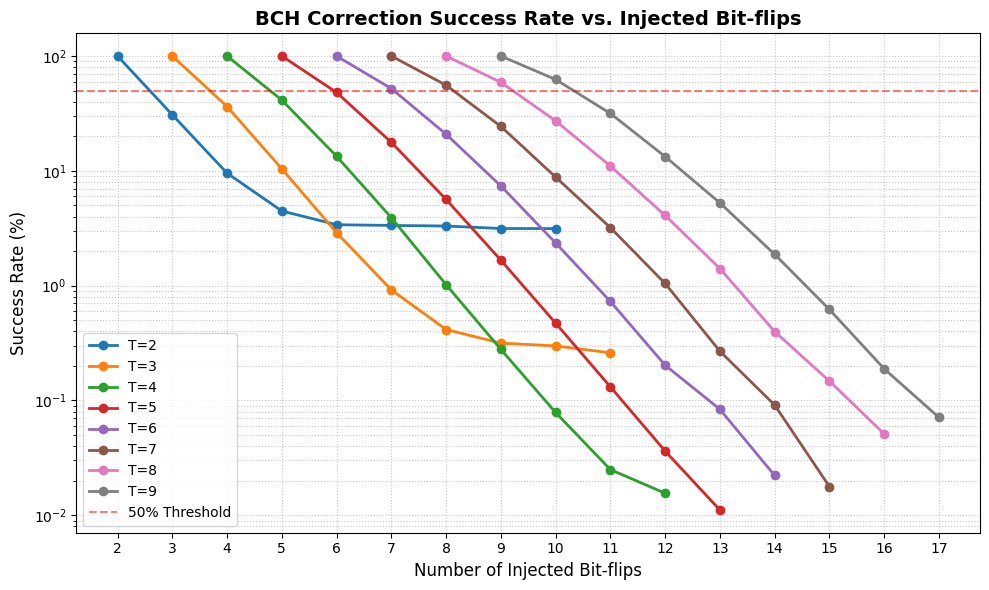

In [ ]:
results = {}

for T in range(a, b):
    bch = bchlib.BCH(T, m=14) 
    bit_flips = T - 1 
    for _ in range(10):
        for n in range(int(c) * (bit_flips + 1 - T)):
            original_data = bytes(random.choices(range(256), k=DATA_SIZE))
            
            # 1. Encode
            data_out, oob_out = encode_sector(original_data)
            
            # 2. Corrupt (Dati + OOB)
            full_packet = bytearray(data_out + oob_out)
            for _ in range(bit_flips):
                # pos = random.randint(0, len(full_packet) - 1)
                # full_packet[pos] ^= (1 << random.randint(0, 7)) 
                pos = random.randint(0, len(full_packet) - 1)
                full_packet[pos] ^= 1 
                
            # 3. Decode 
            corrupted_data_part = bytes(full_packet[:DATA_SIZE])
            corrupted_oob_part = bytes(full_packet[DATA_SIZE:])
            
            recovered_data, status, errs = decode_sector_wo_CRC(corrupted_data_part, corrupted_oob_part)
            
            # 4. Storage
            key = (T, bit_flips)
            if key not in results: results[key] = []
            results[key].append(1 if status != "UNCORRECTABLE" else 0)
        bit_flips +=1


import matplotlib.pyplot as plt
import seaborn as sns # Optional, but makes heatmaps much easier
import numpy as np

# ---------------------------------------------------------
# 1. PROCESS THE DATA
# Calculate the mean success rate (%) for each (T, bit_flips) pair
# ---------------------------------------------------------
success_rates = {}
for key, outcomes in results.items():
    success_rates[key] = np.mean(outcomes) * 100

# Extract unique T values and bit-flips to setup the axes
T_values = sorted(list(set([k[0] for k in success_rates.keys()])))
bit_flip_values = sorted(list(set([k[1] for k in success_rates.keys()])))

# ---------------------------------------------------------
# PLOT 1: Line Chart (Success Rate vs. Bit-flips)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

for T in T_values:
    # 1. Extract ONLY the data points that exist for this specific T
    t_data = [(k[1], rate) for k, rate in success_rates.items() if k[0] == T]
    
    # 2. Sort the data by bit-flips (x-axis) so the line draws cleanly left-to-right
    t_data.sort(key=lambda x: x[0]) 
    
    # 3. Separate into x and y lists
    if t_data:
        x_vals = [item[0] for item in t_data]
        y_vals = [item[1] for item in t_data]
        
        plt.semilogy(x_vals, y_vals, marker='o', linewidth=2, label=f'T={T}')

plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='50% Threshold')
plt.title('BCH Correction Success Rate vs. Injected Bit-flips', fontsize=14, fontweight='bold')
plt.xlabel('Number of Injected Bit-flips', fontsize=12)
plt.ylabel('Success Rate (%)', fontsize=12)
plt.xticks(bit_flip_values)
plt.grid(True, linestyle=':', alpha=0.7, which='both')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
DATA_SIZE = 512  # Data packet size (Payload)
OOB_SIZE = 69    # Out-Of-Band physical space
CRC_SIZE = 4     # 32-bit Checksum
a = 6
b = 7
c = 1e6
results = {}

for T in range(a, b):
    bch = bchlib.BCH(T, m=14) 
    bit_flips = T + 10 
    for _ in range(4):
        for n in range(int(c) * (bit_flips + 1 - T)):
            original_data = bytes(random.choices(range(256), k=DATA_SIZE))
            
            # 1. Encode
            data_out, oob_out = encode_sector(original_data)
            
            # 2. Corrupt (Dati + OOB)
            full_packet = bytearray(data_out + oob_out)
            for _ in range(bit_flips):
                # pos = random.randint(0, len(full_packet) - 1)
                # full_packet[pos] ^= (1 << random.randint(0, 7)) 
                pos = random.randint(0, len(full_packet) - 1)
                full_packet[pos] ^= 1 
                
            # 3. Decode 
            corrupted_data_part = bytes(full_packet[:DATA_SIZE])
            corrupted_oob_part = bytes(full_packet[DATA_SIZE:])
            
            recovered_data, status, errs = decode_sector_wo_CRC(corrupted_data_part, corrupted_oob_part)
            
            # 4. Storage
            key = (T, bit_flips)
            if key not in results: results[key] = []
            results[key].append(1 if status != "UNCORRECTABLE" else 0)
        bit_flips +=1


import matplotlib.pyplot as plt
import seaborn as sns # Optional, but makes heatmaps much easier
import numpy as np

# ---------------------------------------------------------
# 1. PROCESS THE DATA
# Calculate the mean success rate (%) for each (T, bit_flips) pair
# ---------------------------------------------------------
success_rates = {}
for key, outcomes in results.items():
    success_rates[key] = np.mean(outcomes) * 100

# Extract unique T values and bit-flips to setup the axes
T_values = sorted(list(set([k[0] for k in success_rates.keys()])))
bit_flip_values = sorted(list(set([k[1] for k in success_rates.keys()])))

# ---------------------------------------------------------
# PLOT 1: Line Chart (Success Rate vs. Bit-flips)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

for T in T_values:
    # 1. Extract ONLY the data points that exist for this specific T
    t_data = [(k[1], rate) for k, rate in success_rates.items() if k[0] == T]
    
    # 2. Sort the data by bit-flips (x-axis) so the line draws cleanly left-to-right
    t_data.sort(key=lambda x: x[0]) 
    
    # 3. Separate into x and y lists
    if t_data:
        x_vals = [item[0] for item in t_data]
        y_vals = [item[1] for item in t_data]
        
        plt.semilogy(x_vals, y_vals, marker='o', linewidth=2, label=f'T={T}')

plt.axhline(50, color='red', linestyle='--', alpha=0.5, label='50% Threshold')
plt.title('BCH Correction Success Rate vs. Injected Bit-flips', fontsize=14, fontweight='bold')
plt.xlabel('Number of Injected Bit-flips', fontsize=12)
plt.ylabel('Success Rate (%)', fontsize=12)
plt.xticks(bit_flip_values)
plt.grid(True, linestyle=':', alpha=0.7, which='both')
plt.legend()
plt.tight_layout()
plt.show()